In [1]:
! pip install kaggle hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 MB 83.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 82.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [kaggle]2m7/8 [kaggle]t]lugins]


In [2]:
import kagglehub

print("KaggleHub Ready")

KaggleHub Ready


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/teamspace/studios/this_studio/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA Available: True
Using GPU: Tesla T4

image 1/1 /teamspace/studios/this_studio/agrisustain/AgriSustain-AI-System-Field-scale-intelligent-farming-/notebooks/bus.jpg: 640x480 4 persons, 1 bus, 78.4ms
Speed: 11.0ms preprocess, 78.4ms inference, 35.4ms postprocess per image at shape (1, 3, 640, 480)


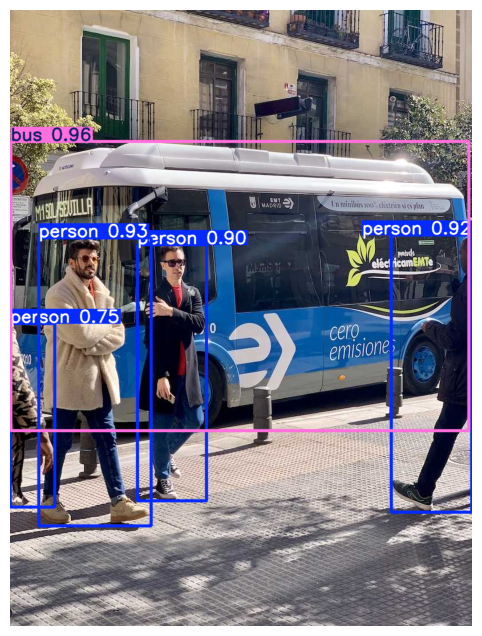

In [1]:
# Cell 1: Environment verification and base test
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Verify GPU availability
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

# 2. Load the base pre-trained model
model = YOLO("yolov8m.pt")

# 3. Test on a generic sample image from the web to check inference pipeline
# This will auto-download a sample image and run an object detection test
results = model("https://ultralytics.com/images/bus.jpg")

# 4. Plot the result inline inside the notebook
for r in results:
    im_array = r.plot()  # Plots the bounding boxes on the image
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

In [2]:
# Cell 2: Test your custom-trained AgriSustain pest detector
# Run this cell AFTER you have run the training script

# 1. Path to your newly trained best weights
custom_weights_path = "../saved_models/pest_detection_run/weights/best.pt"

if os.path.exists(custom_weights_path):
    # 2. Load your custom enterprise model
    custom_model = YOLO(custom_weights_path)
    
    # 3. Path to a local validation image (swap out with a real image file name from your data folder)
    test_image_path = "../data/agrisustain-pests-v1/images/val/YOUR_TEST_IMAGE.jpg"
    
    if os.path.exists(test_image_path):
        # 4. Run inference
        outputs = custom_model(test_image_path)
        
        # 5. Display bounding boxes, crop type, and pest type labels inline
        for out in outputs:
            annotated_img = out.plot()
            plt.figure(figsize=(12, 10))
            plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.show()
    else:
        print(f"Please replace 'YOUR_TEST_IMAGE.jpg' with an actual file inside: {os.path.dirname(test_image_path)}")
else:
    print("Custom weights not found yet. Run your 'src/detection/train_yolo.py' script via the terminal first!")

Please replace 'YOUR_TEST_IMAGE.jpg' with an actual file inside: ../data/agrisustain-pests-v1/images/val
